In [ ]:
#l2

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,  models, callbacks
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train),(x_test, y_test)=tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Normalize (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten 28x28 → 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

In [ ]:
print(x_train.shape)

(60000, 784)


In [ ]:
x_train_small = x_train[:1000]
y_train_small = y_train[:1000]

In [ ]:
model_overfit = models.Sequential([
    layers.Dense(2000, activation='relu', input_shape=(784,)),
    layers.Dense(2000, activation='relu'),
    layers.Dense(2000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_overfit.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
chk_point_overfit = callbacks.ModelCheckpoint(
    filepath="best_overfit_model.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

chk_point_l2 = callbacks.ModelCheckpoint(
    filepath="best_l2_model.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

In [ ]:
history_overfit = model_overfit.fit(
    x_train_small, y_train_small,
    epochs=50,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[chk_point_overfit]
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5282 - loss: 1.4110
Epoch 1: val_accuracy improved from None to 0.82330, saving model to best_overfit_model.keras

Epoch 1: finished saving model to best_overfit_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 389ms/step - accuracy: 0.7140 - loss: 0.9028 - val_accuracy: 0.8233 - val_loss: 0.5694
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9175 - loss: 0.2793
Epoch 2: val_accuracy improved from 0.82330 to 0.88310, saving model to best_overfit_model.keras

Epoch 2: finished saving model to best_overfit_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 392ms/step - accuracy: 0.9180 - loss: 0.2523 - val_accuracy: 0.8831 - val_loss: 0.3940
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9629 - loss: 0.1172
Epoch 3: val_accuracy did not improve from 0.88310
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 340ms/step - accuracy: 0.9600 - loss: 0.1190 - val_accuracy: 0.8826 - val_loss: 0.4136
Epoch 4/50
32/32 ━━━━━━━━━

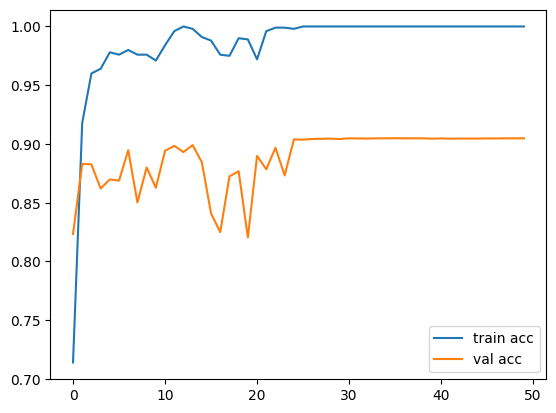

In [ ]:
plt.plot(history_overfit.history['accuracy'], label='train acc')
plt.plot(history_overfit.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [ ]:
model_l2 = models.Sequential([
    layers.Dense(2000, activation='relu', input_shape=(784,),
                 kernel_regularizer=regularizers.l2(0.001)),

    layers.Dense(2000, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),

    layers.Dense(2000, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_l2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_l2 = model_l2.fit(
    x_train_small, y_train_small,
    epochs=50,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[chk_point_l2]
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5517 - loss: 5.7314
Epoch 1: val_accuracy improved from None to 0.82950, saving model to best_l2_model.keras

Epoch 1: finished saving model to best_l2_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 548ms/step - accuracy: 0.7160 - loss: 4.6807 - val_accuracy: 0.8295 - val_loss: 3.2355
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8945 - loss: 2.7475
Epoch 2: val_accuracy improved from 0.82950 to 0.87740, saving model to best_l2_model.keras

Epoch 2: finished saving model to best_l2_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 864ms/step - accuracy: 0.9090 - loss: 2.5081 - val_accuracy: 0.8774 - val_loss: 2.2650
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9648 - loss: 1.8514
Epoch 3: val_accuracy did not improve from 0.87740
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 579ms/step - accuracy: 0.9540 - loss: 1.7582 - val_accuracy: 0.8439 - val_loss: 1.9532
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms

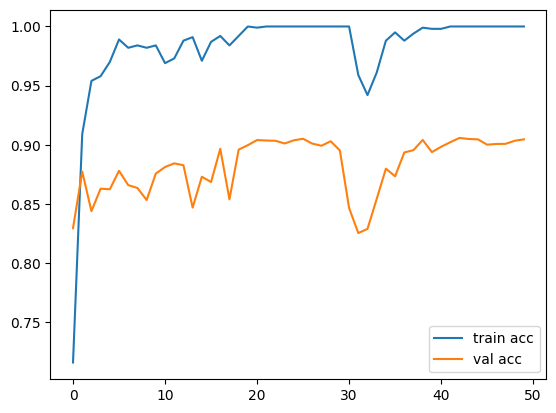

In [ ]:
plt.plot(history_l2.history['accuracy'], label='train acc')
plt.plot(history_l2.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()